<a href="https://colab.research.google.com/github/Omsai-2000/Exploratory-Data-Analysis/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [4]:
dia=pd.read_csv('/content/diabetes.csv')

In [5]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
X=dia.drop('Outcome',axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [7]:
Y=dia['Outcome']
Y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2, random_state=42)

In [9]:
from sklearn import svm
classifier=svm.SVC(kernel='linear', probability=True)
classifier.fit(X_train,Y_train)
Y_pred=classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred)
print(cm)


[[80 19]
 [19 36]]


In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay,roc_curve, auc
import matplotlib.pyplot as plt
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



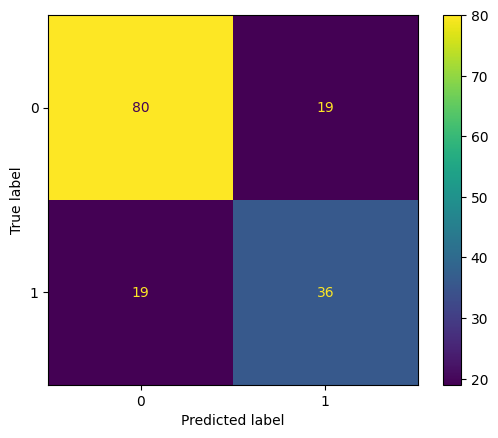

In [11]:
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classifier.classes_)
cm_display.plot()
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score
svc = svm.SVC(kernel='linear', C=1, probability=True)
scores = cross_val_score(svc, X, Y, cv=5)
print(scores)

[0.75974026 0.75324675 0.74025974 0.81045752 0.76470588]


In [14]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5)
grid_search.fit(X_train, Y_train)
grid_search.best_score_

np.float64(0.767119818739171)